# Next-Word Prediction: Exploratory Data Analysis

Predict the next word from the previous few words, the way a phone keyboard does.

Dataset: SwiftKey / HC Corpora — blogs, news and Twitter text (en_US), the real corpus SwiftKey released for this exact task (Coursera Data Science Specialization capstone).

This notebook loads the raw text, cleans and tokenizes it, and answers the questions that decide our modelling choices: how big is the corpus, how long are sentences, how skewed is the word distribution, and how much of the text does a vocabulary of a given size cover?

Before running, build the corpus once with `python scripts/download_data.py` (downloads the ~560 MB archive, extracts it, and samples+mixes the three registers into `data/raw/corpus.txt`). See the project README for details, including how to point this at your own text instead.

## 1. Setup

In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))  # so `import config` and `from src...` work from notebooks/

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from src.dataset import load_corpus, prepare_data
from src.preprocess import Vocabulary, clean_text, split_sentences, tokenize

np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("Corpus:", config.DEFAULT_CORPUS)
print("Outputs:", config.OUTPUTS_DIR)

Corpus: D:\next-word-prediction\data\raw\corpus.txt
Outputs: D:\next-word-prediction\outputs


## 2. Load and inspect the raw text

In [2]:
raw = load_corpus()
print(f"{len(raw):,} characters")
print(raw[3000:3400])

75,268,708 characters
”
u baby
Dont'a Hightower ILB, Alabama
I was so embarrassed for Don Draper.
Michael O'Rourke, San Francisco
"The timing of this departure has been the subject of ongoing discussions for more than 18 months," he said. Jory did not comment further.
#Visual #Designers - want to be the first creative for a small & quickly growing SF #startup? Web Apps are the key!
Torre is tremendous, making Rafael so


## 3. Sentences and tokens

`split_sentences` strips the Gutenberg header and footer, splits on sentence punctuation and blank lines, and tokenizes each sentence to lowercase words.

In [3]:
sentences = split_sentences(raw)
lengths = np.array([len(s) for s in sentences])
all_tokens = [t for s in sentences for t in s]

summary = pd.Series({
    "sentences": len(sentences),
    "tokens": len(all_tokens),
    "unique words": len(set(all_tokens)),
    "mean sentence length": round(lengths.mean(), 1),
    "median sentence length": int(np.median(lengths)),
    "95th percentile length": int(np.percentile(lengths, 95)),
    "longest sentence": int(lengths.max()),
})
summary

sentences                   777817.0
tokens                    13077501.0
unique words                185381.0
mean sentence length            16.8
median sentence length          14.0
95th percentile length          40.0
longest sentence               830.0
dtype: float64

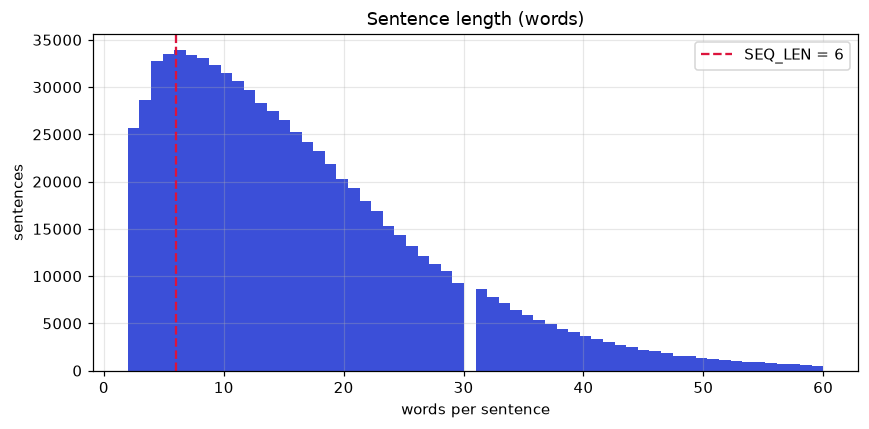

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths[lengths <= 60], bins=60, color="#3b4fd8")
ax.axvline(config.SEQ_LEN, color="crimson", ls="--", label=f"SEQ_LEN = {config.SEQ_LEN}")
ax.set(title="Sentence length (words)", xlabel="words per sentence", ylabel="sentences")
ax.legend()
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "eda_sentence_lengths.png")
plt.show()

## 4. Most frequent words

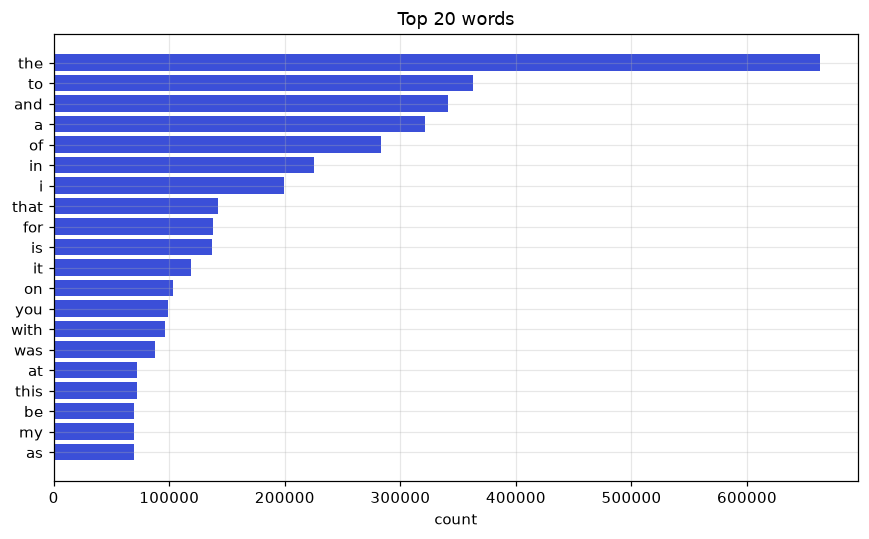

In [5]:
from collections import Counter

counts = Counter(all_tokens)
top = pd.DataFrame(counts.most_common(20), columns=["word", "count"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["word"][::-1], top["count"][::-1], color="#3b4fd8")
ax.set(title="Top 20 words", xlabel="count")
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "eda_top_words.png")
plt.show()

## 5. Zipf's law

Word frequency falls off as a power law: a handful of words are extremely common and most words are rare. This is why a small vocabulary still covers most of the text, and why the rare tail becomes `<unk>`.

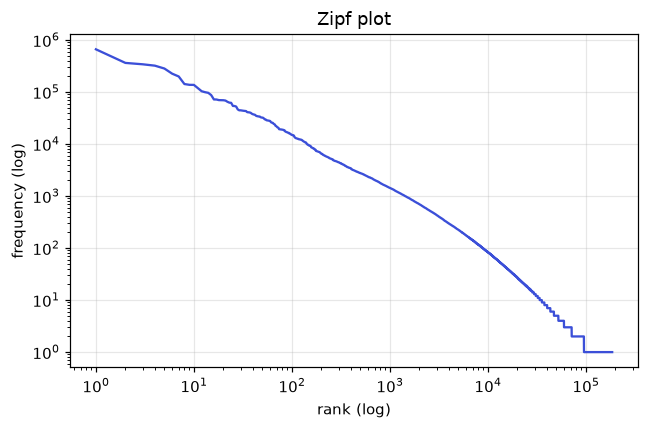

In [6]:
freqs = np.array(sorted(counts.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(ranks, freqs, color="#3b4fd8")
ax.set(title="Zipf plot", xlabel="rank (log)", ylabel="frequency (log)")
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "eda_zipf.png")
plt.show()

## 6. Vocabulary size vs. coverage

How much of the running text is covered if we keep only the top-N words?

In [7]:
cum_cov = np.cumsum(freqs) / freqs.sum()
rows = []
for n in [500, 1000, 2000, 5000, 10000]:
    if n <= len(cum_cov):
        rows.append({"vocab size": n, "token coverage": f"{cum_cov[n - 1]:.1%}"})
pd.DataFrame(rows)

,vocab size,token coverage
0,500,63.0%
1,1000,70.5%
2,2000,78.0%
3,5000,86.9%
4,10000,92.1%


In [8]:
kept = sum(1 for c in counts.values() if c >= config.MIN_FREQ)
print(f"Words seen at least {config.MIN_FREQ}x: {kept:,} of {len(counts):,} unique words")
print(f"Effective vocabulary (MAX_VOCAB={config.MAX_VOCAB:,}): {min(kept, config.MAX_VOCAB - 2) + 2:,} including <pad> and <unk>")

Words seen at least 2x: 95,360 of 185,381 unique words
Effective vocabulary (MAX_VOCAB=10,000): 10,000 including <pad> and <unk>


## 7. Takeaways

- The vocabulary is small enough for a full softmax over every word, so no sampled softmax is needed.
- Most sentences are short, so a context window of `SEQ_LEN` words captures nearly all the usable history, and left padding with `<pad>` (masked in the model) handles the shorter ones.
- Rare words map to `<unk>`. The predictor never suggests `<unk>` or `<pad>`.

Next: `02_preprocessing.ipynb`.